# Web Intelligence: Single-Site RAG Evaluation, site url: https://web-intelligence-red.vercel.app/

Evaluates retrieval + faithfulness for **one site** with charts and metric tables.


In [1]:
import sys, os, json, re, time, datetime
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import seaborn as sns

matplotlib.rcParams['figure.dpi'] = 120
matplotlib.rcParams['font.family'] = 'sans-serif'
sns.set_theme(style='whitegrid', palette='muted')

# NLTK stopwords — used by LlamaIndex eval and RAGAS for token-level metrics
try:
    import nltk
    nltk.download('stopwords', quiet=True)
    from nltk.corpus import stopwords as _nltk_sw
    _NLTK_AVAILABLE = True
except ImportError:
    _NLTK_AVAILABLE = False

BACKEND_DIR = Path('.').resolve()
DATA_DIR = BACKEND_DIR.parent / 'data'
sys.path.insert(0, str(BACKEND_DIR))

from dotenv import load_dotenv
load_dotenv(BACKEND_DIR / '.env')

from embeddings import EmbeddingStore
from rag import answer_question

STORE = EmbeddingStore(DATA_DIR / 'faiss_index')
print('EmbeddingStore ready.')


c:\Users\shiva\miniforge3\envs\webin\lib\site-packages\pinecone\data\index.py:1: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm


EmbeddingStore ready.


## 0. Evaluation Rules & Thresholds

> **Scope: Site Q&A chatbot only.**
> Insights generation intentionally synthesises beyond literal context — exempt.

### Production RAG Evaluation Design

Industry-standard split (used by RAGAS, LlamaIndex Evaluators, TruLens):

```
All eval questions
├── answerable   → Hit@k · MRR · Faithfulness · Hallucination · Ctx Coverage
└── unanswerable → Rejection Rate  (did system correctly refuse?)
```

**Why separate?** Including unanswerable questions in Hit@k or hallucination metrics
contaminates both tracks. A system that refuses all questions scores 0% Hit@1 but 100%
rejection rate — these measure fundamentally different behaviour.

### Quantitative Targets

| Track | Metric | Target | Rationale |
|---|---|---|---|
| Answerable | Hit@1 | ≥ 80% | Top chunk must be relevant |
| Answerable | Hit@5 | ≥ 95% | Near-total recall |
| Answerable | MRR@5 | ≥ 0.75 | Relevant chunk appears early |
| Answerable | Halluc (CW) | ≤ 25% | Content-word tokens not grounded in context |
| Answerable | Ctx Coverage | ≥ 65% | Answer tokens sourced from context |
| Answerable | KW Overlap | ≥ 75% | Domain keywords present in answer |
| Answerable | Avg Words | ≤ 150 | Concise; verbose answers inflate hallucination score |
| Answerable | Ctx Tokens | ≤ 3000 | Context window cost per Q&A call |
| Unanswerable | Rejection Rate | ≥ 90% | System must refuse when context absent |


In [2]:
# ── Site Q&A evaluation thresholds ───────────────────────────────────────────
# ⚠ NOT for Insights generation (high synthesis = intentional there)
RAG_QA_THRESHOLDS = {
    # Answerable-question track
    'hit@1_min':          0.80,
    'hit@5_min':          0.95,
    'mrr@5_min':          0.75,
    'hallucination_max':  0.25,   # content-word hallucination (see §4)
    'ctx_coverage_min':   0.65,
    'kw_overlap_min':     0.75,
    'answer_words_max':   150,    # matches rag.py prompt cap
    'ctx_tokens_max':     3000,
    # Unanswerable-question track
    'rejection_rate_min': 0.90,   # ≥90% of unanswerable Qs must get "I don't know"
}

def threshold_check(name, value, threshold, mode='min'):
    """Return (status_str, delta)."""
    if mode == 'min':
        ok = value >= threshold
        delta = value - threshold
    else:
        ok = value <= threshold
        delta = threshold - value
    return ('✅ PASS' if ok else '❌ FAIL'), delta

print('Evaluation thresholds (Q&A chatbot scope only):')
print('  ANSWERABLE TRACK')
print(f'    Hit@1          ≥ {RAG_QA_THRESHOLDS["hit@1_min"]:.0%}')
print(f'    Hit@5          ≥ {RAG_QA_THRESHOLDS["hit@5_min"]:.0%}')
print(f'    MRR@5          ≥ {RAG_QA_THRESHOLDS["mrr@5_min"]:.2f}')
print(f'    Hallucination  ≤ {RAG_QA_THRESHOLDS["hallucination_max"]:.0%}')
print(f'    Ctx Coverage   ≥ {RAG_QA_THRESHOLDS["ctx_coverage_min"]:.0%}')
print(f'    KW Overlap     ≥ {RAG_QA_THRESHOLDS["kw_overlap_min"]:.0%}')
print(f'    Answer Words   ≤ {RAG_QA_THRESHOLDS["answer_words_max"]} words')
print(f'    Ctx Tokens     ≤ {RAG_QA_THRESHOLDS["ctx_tokens_max"]} est.')
print('  UNANSWERABLE TRACK')
print(f'    Rejection Rate ≥ {RAG_QA_THRESHOLDS["rejection_rate_min"]:.0%}')


Evaluation thresholds (Q&A chatbot scope only):
  ANSWERABLE TRACK
    Hit@1          ≥ 80%
    Hit@5          ≥ 95%
    MRR@5          ≥ 0.75
    Hallucination  ≤ 25%
    Ctx Coverage   ≥ 65%
    KW Overlap     ≥ 75%
    Answer Words   ≤ 150 words
    Ctx Tokens     ≤ 3000 est.
  UNANSWERABLE TRACK
    Rejection Rate ≥ 90%


## 1. Configure Target Site

Set `TARGET_URL` to any URL already processed. The notebook resolves its session automatically.

In [3]:
# ── CONFIGURE THIS ────────────────────────────────────────────────────────────
TARGET_URL = 'https://www.bbc.co.uk/aboutthebbc' #'https://www.aboutamazon.com/what-we-do'
TOP_K      = 5                             # chunks to retrieve per query
# ─────────────────────────────────────────────────────────────────────────────

# Auto-resolve session from sessions directory
def find_session(url: str) -> dict | None:
    for p in sorted((DATA_DIR / 'sessions').glob('*.json')):
        try:
            data = json.loads(p.read_text(encoding='utf-8'))
            if any(url.rstrip('/') in u for u in data.get('urls', [])):
                return data
        except Exception:
            pass
    return None

session = find_session(TARGET_URL)
assert session, f'No session found for {TARGET_URL}. Run /api/process first.'

SESSION_ID = session['session_id']
SITE_LABEL = TARGET_URL.split('//')[-1].split('/')[0]

print(f'Site      : {SITE_LABEL}')
print(f'Session   : {SESSION_ID}')
print(f'Pages     : {session["page_count"]}')
print(f'Chunks    : {len(session["chunks"])}')
print(f'URLs      : {session["urls"]}')

Site      : www.bbc.co.uk
Session   : 2386354aecfc0764
Pages     : 49
Chunks    : 782
URLs      : ['https://www.bbc.co.uk/aboutthebbc']


## 2. Eval Questions

10 questions auto-seeded for known sites. For a new site, edit `EVAL_QA` directly.

In [4]:
# Preset Q&A banks per known site (extend freely)
# Each entry has:
#   q           — question text
#   gt          — ground truth answer (answerable only)
#   kw          — keywords expected in retrieved chunks (answerable only)
#   answerable  — True: context should exist; False: system must refuse

_PRESETS = {
    'aboutamazon.com': [
        # ── Answerable ──────────────────────────────────────────────────────
        {'q': 'What does Amazon do as a company?',
         'gt': 'Amazon builds and operates businesses focused on e-commerce, cloud computing, devices, and digital services.',
         'kw': ['ecommerce', 'cloud', 'devices', 'services', 'businesses'],
         'answerable': True},
        {'q': 'What is Amazon Web Services (AWS)?',
         'gt': 'AWS is Amazon cloud computing platform providing infrastructure and services to businesses.',
         'kw': ['aws', 'cloud', 'infrastructure', 'services'],
         'answerable': True},
        {'q': 'What kinds of products and services does Amazon offer?',
         'gt': 'Amazon offers retail products, digital content, cloud services, smart devices, and logistics solutions.',
         'kw': ['retail', 'digital', 'cloud', 'devices', 'logistics'],
         'answerable': True},
        {'q': 'What is Amazon approach to innovation?',
         'gt': 'Amazon focuses on customer obsession, long-term thinking, and continuous innovation across its businesses.',
         'kw': ['innovation', 'customer', 'long-term', 'thinking'],
         'answerable': True},
        {'q': 'What industries does Amazon operate in?',
         'gt': 'Amazon operates in retail, technology, cloud computing, entertainment, and logistics industries.',
         'kw': ['retail', 'technology', 'cloud', 'entertainment', 'logistics'],
         'answerable': True},
        # ── Unanswerable — context will NOT contain these answers ────────────
        {'q': 'What is Amazon net profit margin for the last quarter?',
         'gt': '',
         'kw': [],
         'answerable': False},
        {'q': 'How many Amazon employees work in Germany specifically?',
         'gt': '',
         'kw': [],
         'answerable': False},
        {'q': 'What programming language is the Alexa backend written in?',
         'gt': '',
         'kw': [],
         'answerable': False},
    ],

    'premierleague.com': [
        # ── Answerable ──────────────────────────────────────────────────────
        {'q': 'What is the Premier League?',
         'gt': 'The Premier League is the top level of professional football league competition in England.',
         'kw': ['football', 'league', 'england', 'top level'],
         'answerable': True},
        {'q': 'When was the Premier League founded?',
         'gt': 'The Premier League was founded in 1992.',
         'kw': ['1992', 'founded'],
         'answerable': True},
        {'q': 'How many clubs compete in the Premier League?',
         'gt': '20 clubs compete in the Premier League each season.',
         'kw': ['20', 'clubs', 'teams'],
         'answerable': True},
        {'q': 'How does promotion and relegation work in the Premier League?',
         'gt': 'The bottom three teams are relegated to the Championship and replaced by promoted teams.',
         'kw': ['relegation', 'promotion', 'bottom three', 'championship'],
         'answerable': True},
        {'q': 'What makes the Premier League popular globally?',
         'gt': 'It is widely watched worldwide due to its competitive matches, global fanbase, and broadcast reach.',
         'kw': ['global', 'fans', 'broadcast', 'popular'],
         'answerable': True},
        # ── Unanswerable ─────────────────────────────────────────────────────
        {'q': 'What was the exact transfer fee paid for a specific player this season?',
         'gt': '', 'kw': [], 'answerable': False},
        {'q': 'What is the combined shirt sponsorship revenue across all 20 clubs?',
         'gt': '', 'kw': [], 'answerable': False},
    ],

    'bbc.co.uk': [
        # ── Answerable ──────────────────────────────────────────────────────
        {'q': 'What is the BBC?',
         'gt': 'The BBC is the United Kingdom public service broadcaster.',
         'kw': ['bbc', 'public service', 'broadcaster', 'uk'],
         'answerable': True},
        {'q': 'How is the BBC funded?',
         'gt': 'The BBC is primarily funded by the television licence fee paid by UK households.',
         'kw': ['funded', 'licence fee', 'tv licence'],
         'answerable': True},
        {'q': 'What is the mission of the BBC?',
         'gt': 'The BBC aims to inform, educate and entertain audiences.',
         'kw': ['inform', 'educate', 'entertain'],
         'answerable': True},
        {'q': 'Is the BBC independent from the government?',
         'gt': 'Yes, the BBC operates independently but is publicly funded and governed by a charter.',
         'kw': ['independent', 'government', 'charter'],
         'answerable': True},
        {'q': 'What services does the BBC provide?',
         'gt': 'The BBC provides television, radio, online content, and news services.',
         'kw': ['tv', 'radio', 'online', 'news', 'services'],
         'answerable': True},
        # ── Unanswerable ─────────────────────────────────────────────────────
        {'q': 'What is the BBC pension fund total asset value?',
         'gt': '', 'kw': [], 'answerable': False},
        {'q': 'How many BBC journalists were made redundant in 2023?',
         'gt': '', 'kw': [], 'answerable': False},
    ],
}

# ── Backwards-compat: _PRESETS_ still available ───────────────────────────────
_PRESETS_ = {
    'aboutamazon.com': [
        {'q': 'How does Amazon combine retail and cloud services in its business model?',
         'gt': 'Amazon operates both e-commerce and cloud computing through AWS as part of its diversified business model.',
         'kw': ['ecommerce','cloud','aws','business model'],
         'answerable': True},
        {'q': 'What principles guide Amazon innovation strategy?',
         'gt': 'Amazon focuses on customer obsession, long-term thinking, and continuous innovation.',
         'kw': ['customer','long-term','innovation'],
         'answerable': True},
        {'q': 'How does Amazon support third-party sellers?',
         'gt': 'Amazon provides tools, logistics, and marketplace access to third-party sellers.',
         'kw': ['third-party','sellers','marketplace','logistics'],
         'answerable': True},
        {'q': 'What role do devices play in Amazon ecosystem?',
         'gt': 'Devices like Alexa and Kindle extend Amazon services into customer environments.',
         'kw': ['devices','alexa','kindle'],
         'answerable': True},
        {'q': 'What industries does Amazon operate across and how are they connected?',
         'gt': 'Amazon operates in retail, cloud, entertainment, and logistics, integrated through its platform.',
         'kw': ['retail','cloud','entertainment','logistics'],
         'answerable': True},
    ]
}

# ── Resolve preset and split into tracks ──────────────────────────────────────
preset_key = next((k for k in _PRESETS if k in SITE_LABEL), None)
EVAL_QA = _PRESETS.get(preset_key, [])

ANSWERABLE_QA   = [qa for qa in EVAL_QA if qa.get('answerable', True)]
UNANSWERABLE_QA = [qa for qa in EVAL_QA if not qa.get('answerable', True)]

if not EVAL_QA:
    print('No preset for this site. Edit EVAL_QA below with answerable/unanswerable entries.')
else:
    print(f'Loaded {len(EVAL_QA)} questions for [{SITE_LABEL}]')
    print(f'  Answerable   : {len(ANSWERABLE_QA)} questions (retrieval + faithfulness track)')
    print(f'  Unanswerable : {len(UNANSWERABLE_QA)} questions (rejection rate track)')
    print()
    print('ANSWERABLE:')
    for i, qa in enumerate(ANSWERABLE_QA, 1):
        print(f'  A{i:02d}: {qa["q"]}')
    if UNANSWERABLE_QA:
        print('UNANSWERABLE:')
        for i, qa in enumerate(UNANSWERABLE_QA, 1):
            print(f'  U{i:02d}: {qa["q"]}')


Loaded 7 questions for [www.bbc.co.uk]
  Answerable   : 5 questions (retrieval + faithfulness track)
  Unanswerable : 2 questions (rejection rate track)

ANSWERABLE:
  A01: What is the BBC?
  A02: How is the BBC funded?
  A03: What is the mission of the BBC?
  A04: Is the BBC independent from the government?
  A05: What services does the BBC provide?
UNANSWERABLE:
  U01: What is the BBC pension fund total asset value?
  U02: How many BBC journalists were made redundant in 2023?


## 3. Run Retrieval Evaluation

In [5]:
def _norm_kw(s: str) -> str:
    """Normalise for matching: lowercase, strip hyphens/underscores/spaces."""
    return re.sub(r'[-_\s]', '', s.lower())

def chunk_hit(chunk_text: str, keywords: list) -> bool:
    # Normalise both sides: 'ecommerce' matches 'e-commerce' in chunk text
    t_norm = _norm_kw(chunk_text)
    return any(_norm_kw(kw) in t_norm for kw in keywords)

def retrieval_metrics(results: list, keywords: list, ks=(1, 3, 5)) -> dict:
    rel = [chunk_hit(r['chunk']['text'], keywords) for r in results]
    scores = [r['score'] for r in results]
    m = {f'hit@{k}': int(any(rel[:k])) for k in ks}
    mrr = next((1.0 / (i + 1) for i, r in enumerate(rel[:5]) if r), 0.0)
    m['mrr@5'] = mrr
    m['precision@5'] = sum(rel[:5]) / min(5, len(rel)) if rel else 0.0
    m['mean_score'] = sum(scores) / len(scores) if scores else 0.0
    m['top_scores'] = scores[:5]
    return m

# ── Run retrieval eval on ANSWERABLE questions only ───────────────────────────
# Unanswerable questions belong to the rejection-rate track (Section 4 eval)
retrieval_rows = []
print(f'Retrieval eval — top_k={TOP_K} | {len(ANSWERABLE_QA)} answerable questions\n')

for i, qa in enumerate(ANSWERABLE_QA):
    try:
        results = STORE.query(SESSION_ID, qa['q'], top_k=TOP_K)
        m = retrieval_metrics(results, qa['kw'])
    except Exception as e:
        print(f'  ERROR Q{i+1}: {e}')
        results = []
        m = {'hit@1': 0, 'hit@3': 0, 'hit@5': 0, 'mrr@5': 0.0,
             'precision@5': 0.0, 'mean_score': 0.0, 'top_scores': []}

    retrieval_rows.append({'idx': i + 1, **qa, 'results': results, **m})
    tag = 'HIT' if m['hit@5'] else 'MISS'
    print(f'  [{tag}] A{i+1:02d} hit@1={m["hit@1"]} hit@3={m["hit@3"]} '
          f'hit@5={m["hit@5"]} mrr={m["mrr@5"]:.2f} score={m["mean_score"]:.3f} | {qa["q"][:55]}')

print('\nRetrieval done (answerable track).')


Retrieval eval — top_k=5 | 5 answerable questions

  [HIT] A01 hit@1=1 hit@3=1 hit@5=1 mrr=1.00 score=0.848 | What is the BBC?
  [HIT] A02 hit@1=1 hit@3=1 hit@5=1 mrr=1.00 score=0.853 | How is the BBC funded?
  [HIT] A03 hit@1=0 hit@3=1 hit@5=1 mrr=0.50 score=0.858 | What is the mission of the BBC?
  [HIT] A04 hit@1=1 hit@3=1 hit@5=1 mrr=1.00 score=0.833 | Is the BBC independent from the government?
  [HIT] A05 hit@1=1 hit@3=1 hit@5=1 mrr=1.00 score=0.853 | What services does the BBC provide?

Retrieval done (answerable track).


## 3.5. Hit@1 Failure Diagnosis

For each question where Hit@1 = 0 (top chunk not relevant), show:
- What the top-ranked chunk actually contains
- Which keywords were expected
- Why the semantic similarity was high but keyword match failed

This distinguishes two failure modes:
1. **Semantic mismatch** — embedding matched wrong topic (query intent ≠ chunk topic)
2. **Keyword gap** — chunk IS relevant but uses different surface form of keyword


In [6]:
hit1_failures = [r for r in retrieval_rows if r['hit@1'] == 0]

if not hit1_failures:
    print('No Hit@1 failures — all top chunks are relevant.')
else:
    print(f'Hit@1 FAILURES: {len(hit1_failures)} question(s)\n')
    print('=' * 80)

    for r in hit1_failures:
        top_result = r['results'][0] if r['results'] else None
        print(f'Q{r["idx"]:02d}: {r["q"]}')
        print(f'  Expected keywords : {r["kw"]}')
        print(f'  Top chunk score   : {top_result["score"]:.3f}' if top_result else '  No results')

        if top_result:
            chunk_text = top_result['chunk']['text']
            section    = top_result['chunk'].get('section_title', 'n/a')

            # Check which keywords (normalised) are in each top-5 chunk
            print(f'  Top chunk section : {section}')
            print(f'  Top chunk text    : {chunk_text[:200]}...')
            print()

            # Keyword presence per rank
            print('  Keyword match per rank:')
            for rank, res in enumerate(r['results'][:5], 1):
                ct = res['chunk']['text']
                matches = [kw for kw in r['kw'] if _norm_kw(kw) in _norm_kw(ct)]
                hit = bool(matches)
                print(f'    Rank {rank} (score={res["score"]:.3f}): {"HIT" if hit else "miss"}'
                      f'  matched={matches if matches else "none"}'
                      f'  section={res["chunk"].get("section_title","")[:40]}')
            print()

            # Diagnosis
            # Check if top chunk has ANY of the keywords in original or normalised form
            raw_miss = not any(kw.lower() in chunk_text.lower() for kw in r['kw'])
            norm_miss = not any(_norm_kw(kw) in _norm_kw(chunk_text) for kw in r['kw'])

            if norm_miss:
                print(f'  DIAGNOSIS: Semantic mismatch.')
                print(f'    The top chunk is semantically related (score {top_result["score"]:.3f})')
                print(f'    but covers a DIFFERENT ASPECT of the topic than the expected keywords.')
                print(f'    The retriever found the most similar chunk, but it does not contain')
                print(f'    the specific sub-topic the question targets.')
                print(f'    Fix options:')
                print(f'      a) Expand keywords to include terms actually present in top chunk')
                print(f'      b) Add a re-ranking step that weights keyword presence')
                print(f'      c) Ensure chunk covers the expected sub-topic (chunking strategy)')
            elif raw_miss and not norm_miss:
                print(f'  DIAGNOSIS: Keyword surface-form mismatch (hyphen/spacing variant).')
                print(f'    Fixed by _norm_kw() normalisation — should now be HIT after re-run.')
            print('-' * 80)

# Show what the correct (keyword-containing) chunk looks like vs top chunk
print()
print('FIRST RELEVANT CHUNK (where hit first occurs) vs TOP CHUNK:')
print('=' * 80)
for r in hit1_failures:
    first_hit_rank = next((i+1 for i, res in enumerate(r['results'][:5])
                           if chunk_hit(res['chunk']['text'], r['kw'])), None)
    if first_hit_rank and first_hit_rank > 1:
        top_chunk = r['results'][0]['chunk']
        hit_chunk = r['results'][first_hit_rank - 1]['chunk']
        print(f'Q{r["idx"]:02d} | Top (rank 1, score={r["results"][0]["score"]:.3f}):')
        print(f'  Section: {top_chunk.get("section_title","")}')
        print(f'  Text   : {top_chunk["text"][:150]}')
        print(f'Q{r["idx"]:02d} | First relevant (rank {first_hit_rank}, '
              f'score={r["results"][first_hit_rank-1]["score"]:.3f}):')
        print(f'  Section: {hit_chunk.get("section_title","")}')
        print(f'  Text   : {hit_chunk["text"][:150]}')
        score_gap = r["results"][0]["score"] - r["results"][first_hit_rank-1]["score"]
        print(f'  Score gap (top - relevant): {score_gap:.3f}'
              f'  {"Large gap → embedding bias" if score_gap > 0.02 else "Small gap → borderline case"}')
        print('-' * 80)


Hit@1 FAILURES: 1 question(s)

Q03: What is the mission of the BBC?
  Expected keywords : ['inform', 'educate', 'entertain']
  Top chunk score   : 0.877
  Top chunk section : Overview
  Top chunk text    : The Royal Charter states that the BBCâs object is âthe fulfilment of its Mission and the promotion of its Public Purposesâ...

  Keyword match per rank:
    Rank 1 (score=0.877): miss  matched=none  section=Overview
    Rank 2 (score=0.857): HIT  matched=['inform', 'educate', 'entertain']  section=Mission, values and public purposes
    Rank 3 (score=0.854): HIT  matched=['inform', 'educate', 'entertain']  section=The BBC's Role in Today's World
    Rank 4 (score=0.852): HIT  matched=['inform']  section=BBC World Service
    Rank 5 (score=0.852): miss  matched=none  section=BBC Board

  DIAGNOSIS: Semantic mismatch.
    The top chunk is semantically related (score 0.877)
    but covers a DIFFERENT ASPECT of the topic than the expected keywords.
    The retriever found the most 

## 4. Run Faithfulness Evaluation (LLM calls)

In [7]:
# ── Stopwords: NLTK (LlamaIndex / RAGAS technique) with tech-domain tweaks ────
# NLTK provides 179 English stopwords vs 60 in hand-crafted list.
# LlamaIndex's KeywordNodePostprocessor and RAGAS faithfulness scorer both use
# NLTK stopwords as the baseline for token-level relevance computation.
if _NLTK_AVAILABLE:
    from nltk.corpus import stopwords as _nltk_sw
    STOPWORDS = set(_nltk_sw.words('english'))
    # Retain negations and quantity words — semantically meaningful in Q&A
    STOPWORDS -= {'no', 'not', 'nor', 'never', 'only', 'own', 'above', 'below',
                  'more', 'most', 'few', 'less', 'both', 'each', 'same', 'other'}
    _SW_SOURCE = f'NLTK ({len(STOPWORDS)} words, negations retained)'
else:
    # Fallback: expanded manual list (used if NLTK unavailable)
    STOPWORDS = {
        'the','and','for','are','was','has','have','had','with','this','that',
        'from','they','been','will','more','its','but','not','can','also',
        'our','their','which','what','who','how','use','used','using','one',
        'all','any','some','each','than','then','when','where','were','into',
        'new','now','you','your','per','get','set','may','via','such','well',
        'both','just','very','most','many','much','even','still','over','only',
        'about','after','before','between','through','while','these','those',
        'other','first','last','next','same','long','good','great','high','low',
        'like','make','take','give','work','include','provide','offer','help',
        'part','number','based','called','known','given','show','found','made',
        'being','doing','having','making','taking','going','coming','getting',
        'able','available','different','including','following','provides',
        'offers','allows','enables','supports','creates','builds','runs',
        'operates','manages','serves','uses','ensures','focuses','combines',
        'across','within','around','along','against','toward','whether','though',
    }
    _SW_SOURCE = f'fallback manual ({len(STOPWORDS)} words)'

print(f'Stopwords source: {_SW_SOURCE}')

# ── Abstention detection ───────────────────────────────────────────────────────
# These phrases match the exact refusal pattern in rag.py's prompt
_ABSTENTION_PHRASES = [
    "sorry, i couldn't find this information",
    "i couldn't find this information",
    "couldn't find this information",
    "no relevant information",
    "not available in the context",
]

def is_abstention(answer: str) -> bool:
    """True if the LLM correctly refused to answer (no relevant context)."""
    a = answer.lower().strip()
    return any(phrase in a for phrase in _ABSTENTION_PHRASES)

# ── Token-level metrics ────────────────────────────────────────────────────────
def tokenize(text: str) -> set:
    return set(re.findall(r'\b[a-z]{3,}\b', text.lower()))

def kw_overlap(answer: str, keywords: list) -> float:
    a = answer.lower()
    return sum(1 for kw in keywords if kw.lower() in a) / len(keywords) if keywords else 0.0

def ctx_coverage(answer: str, chunks: list) -> float:
    """Fraction of answer content-words present in retrieved context."""
    if not chunks:
        return 0.0
    ctx = tokenize(' '.join(c['chunk']['text'] for c in chunks)) - STOPWORDS
    ans = tokenize(answer) - STOPWORDS
    return len(ans & ctx) / len(ans) if ans else 0.0

def content_word_hallucination(answer: str, chunks: list) -> float:
    """
    Hallucination on content-bearing words only (≥5 chars, non-stopword).
    Matches LlamaIndex FaithfulnessEvaluator token-overlap strategy.
    Lower = better grounded.
    """
    if not chunks:
        return 1.0
    ctx_words = tokenize(' '.join(c['chunk']['text'] for c in chunks)) - STOPWORDS
    ans_content = {w for w in tokenize(answer) - STOPWORDS if len(w) >= 5}
    if not ans_content:
        return 0.0
    return len(ans_content - ctx_words) / len(ans_content)

def verbosity_score(answer_words: int, max_words: int = 150) -> float:
    return min(1.0, max(0.0, (answer_words - max_words) / max_words))

def estimate_ctx_tokens(chunks: list) -> int:
    return max(1, sum(len(c['chunk']['text']) for c in chunks) // 4)

# ─────────────────────────────────────────────────────────────────────────────
# ANSWERABLE TRACK — faithfulness eval
# ─────────────────────────────────────────────────────────────────────────────
faithfulness_rows = []
print(f'\nAnswerable faithfulness eval — {len(ANSWERABLE_QA)} LLM calls...\n')
print(f'  {"Q#":<4} {"kw":>6} {"ctx":>6} {"hall_raw":>9} {"hall_cw":>8} {"words":>6} {"ctx_tok":>8}  Question')
print('  ' + '-' * 78)

for i, qa in enumerate(ANSWERABLE_QA):
    t0 = time.time()
    try:
        out = answer_question(STORE, SESSION_ID, qa['q'], top_k=TOP_K)
        answer    = out['answer']
        retrieved = retrieval_rows[i]['results']

        cov      = ctx_coverage(answer, retrieved)
        hall_raw = 1.0 - cov
        hall_cw  = content_word_hallucination(answer, retrieved)
        w_count  = len(answer.split())
        v_score  = verbosity_score(w_count)
        ctx_tok  = estimate_ctx_tokens(retrieved)

        row = {
            'idx': i + 1, 'label': f'A{i+1:02d}', 'question': qa['q'],
            'ground_truth': qa['gt'], 'answer': answer,
            'kw_overlap': kw_overlap(answer, qa['kw']),
            'ctx_coverage': cov,
            'hallucination': hall_raw,
            'hallucination_cw': hall_cw,
            'verbosity_score': v_score,
            'answer_words': w_count,
            'ctx_tokens': ctx_tok,
            'num_sources': len(out['sources']),
            'latency_s': time.time() - t0,
            'answerable': True,
            'abstained': is_abstention(answer),
        }
    except Exception as e:
        print(f'  ERROR A{i+1}: {e}')
        row = {
            'idx': i+1, 'label': f'A{i+1:02d}', 'question': qa['q'],
            'ground_truth': qa['gt'], 'answer': '', 'kw_overlap': 0.0,
            'ctx_coverage': 0.0, 'hallucination': 1.0, 'hallucination_cw': 1.0,
            'verbosity_score': 0.0, 'answer_words': 0, 'ctx_tokens': 0,
            'num_sources': 0, 'latency_s': 0.0, 'answerable': True, 'abstained': False,
        }

    faithfulness_rows.append(row)

    hall_flag = ' !' if row['hallucination_cw'] > RAG_QA_THRESHOLDS['hallucination_max'] else ''
    verb_flag = ' [V]' if row['verbosity_score'] > 0 else ''
    print(f'  A{i+1:02d}  {row["kw_overlap"]:>5.0%} {row["ctx_coverage"]:>6.0%}'
          f'  {row["hallucination"]:>8.0%}  {row["hallucination_cw"]:>7.0%}{hall_flag}'
          f'  {row["answer_words"]:>5}{verb_flag}  {ctx_tok:>7}  {qa["q"][:38]}')

# ─────────────────────────────────────────────────────────────────────────────
# UNANSWERABLE TRACK — rejection rate eval
# ─────────────────────────────────────────────────────────────────────────────
rejection_rows = []

if UNANSWERABLE_QA:
    print(f'\nUnanswerable rejection eval — {len(UNANSWERABLE_QA)} LLM calls...\n')
    for i, qa in enumerate(UNANSWERABLE_QA):
        t0 = time.time()
        try:
            out    = answer_question(STORE, SESSION_ID, qa['q'], top_k=TOP_K)
            answer = out['answer']
            abstained = is_abstention(answer)
            row = {
                'idx': i + 1, 'label': f'U{i+1:02d}',
                'question': qa['q'], 'answer': answer,
                'abstained': abstained,
                'answer_words': len(answer.split()),
                'latency_s': time.time() - t0,
                'answerable': False,
            }
        except Exception as e:
            print(f'  ERROR U{i+1}: {e}')
            row = {'idx': i+1, 'label': f'U{i+1:02d}', 'question': qa['q'],
                   'answer': '', 'abstained': False, 'answer_words': 0,
                   'latency_s': 0.0, 'answerable': False}

        rejection_rows.append(row)
        status = '✅ REFUSED' if row['abstained'] else '❌ HALLUCINATED'
        print(f'  {row["label"]}  [{status}]  words={row["answer_words"]}  {qa["q"][:55]}')
        if not row['abstained']:
            # Show first 120 chars of hallucinated answer as evidence
            print(f'       Answer: {row["answer"][:120]}...')

    rejection_rate = sum(r['abstained'] for r in rejection_rows) / len(rejection_rows)
    rr_status, _ = threshold_check('rejection_rate', rejection_rate,
                                    RAG_QA_THRESHOLDS['rejection_rate_min'])
    print(f'\n  Rejection rate: {rejection_rate:.0%}  {rr_status}')
else:
    print('\nNo unanswerable questions defined for this site.')

print('\nFaithfulness eval done.')


Stopwords source: NLTK (184 words, negations retained)

Answerable faithfulness eval — 5 LLM calls...

  Q#       kw    ctx  hall_raw  hall_cw  words  ctx_tok  Question
  ------------------------------------------------------------------------------
  A01   100%    77%       23%      26% !     96      761  What is the BBC?
  A02    33%    72%       28%      25%     65      647  How is the BBC funded?
  A03   100%    94%        6%       7%     27     1721  What is the mission of the BBC?
  A04    67%    67%       33%      29% !     53      935  Is the BBC independent from the govern
  A05   100%    86%       14%      12%     93      623  What services does the BBC provide?

Unanswerable rejection eval — 2 LLM calls...

  U01  [✅ REFUSED]  words=10  What is the BBC pension fund total asset value?
  U02  [✅ REFUSED]  words=10  How many BBC journalists were made redundant in 2023?

  Rejection rate: 100%  ✅ PASS

Faithfulness eval done.


## 4.5. Hallucination Source Breakdown

For each question, identify the **specific answer words** that were NOT found in
any retrieved context chunk. These are the hallucination-contributing tokens.

Two patterns:
- **LLM knowledge leakage** — specific proper nouns / brand terms from training data
- **Connector expansion** — generic elaboration phrases the LLM adds (not factual risk)

Understanding the split determines whether to fix via prompt (leakage) or metric calibration (connectors).


In [8]:
print('HALLUCINATION SOURCE BREAKDOWN')
print('=' * 80)
print('Content words in answer NOT found in any retrieved context chunk')
print('(≥5-char, non-stopword tokens — these drive the hallucination_cw metric)')
print()

PROPER_NOUN_PATTERNS = re.compile(
    r'\b(prime|alexa|kindle|echo|alexa|fulfillment|rekognition|sagemaker|'
    r'comprehend|transcribe|polly|quicksight|redshift|dynamodb|cloudfront|'
    r'sustainability|innovation|obsession|pledge|workforce|upskilling|'
    r'reinvent|reorder|ambition|operational|efficiency|excellence)\b',
    re.IGNORECASE
)

for fr in faithfulness_rows:
    retrieved = retrieval_rows[fr['idx'] - 1]['results']
    if not retrieved:
        continue

    ctx_words   = tokenize(' '.join(c['chunk']['text'] for c in retrieved)) - STOPWORDS
    ans_content = {w for w in tokenize(fr['answer']) - STOPWORDS if len(w) >= 5}
    not_in_ctx  = sorted(ans_content - ctx_words)

    # Classify each hallucinated word
    likely_leakage   = [w for w in not_in_ctx if PROPER_NOUN_PATTERNS.match(w)]
    connector_expand = [w for w in not_in_ctx if not PROPER_NOUN_PATTERNS.match(w)]

    print(f'Q{fr["idx"]:02d}: hall_cw={fr["hallucination_cw"]:.0%}  '
          f'words={fr["answer_words"]}  ctx_coverage={fr["ctx_coverage"]:.0%}')
    print(f'  Total content-word hallucinations: {len(not_in_ctx)} / {len(ans_content)} '
          f'({len(not_in_ctx)/max(1,len(ans_content)):.0%})')

    if likely_leakage:
        print(f'  LLM knowledge leakage ({len(likely_leakage)} words): {", ".join(likely_leakage[:15])}')
        print(f'    -> These are specific terms the LLM knows about the subject but')
        print(f'       are NOT in the retrieved chunks. Root cause: prompt allows training knowledge.')
    if connector_expand:
        print(f'  Connector/expansion words ({len(connector_expand)} words): {", ".join(connector_expand[:15])}')
        print(f'    -> Generic elaboration tokens. Less risky factually but inflate metric.')
    print()

print('FIX APPLIED TO rag.py:')
print('  OLD: "Prioritise the provided context" + "Under 400 words"')
print('  NEW: "ONLY use information explicitly present in the CONTEXT" + "Under 150 words"')
print()
print('EXPECTED IMPACT AFTER RE-RUN:')
print('  hall_cw   : ~41% → target ≤25% (LLM no longer adds training knowledge)')
print('  words     : ~219 → target ≤150  (hard cap enforced in prompt)')
print('  ctx_cov   : ~59% → target ≥65%  (fewer non-context tokens in answer)')


HALLUCINATION SOURCE BREAKDOWN
Content words in answer NOT found in any retrieved context chunk
(≥5-char, non-stopword tokens — these drive the hallucination_cw metric)

Q01: hall_cw=26%  words=96  ctx_coverage=77%
  Total content-word hallucinations: 13 / 50 (26%)
  Connector/expansion words (13 words): bodies, corporation, extensive, governance, leading, offering, other, oversight, overview, platforms, provided, regulatory, worldwide
    -> Generic elaboration tokens. Less risky factually but inflate metric.

Q02: hall_cw=25%  words=65  ctx_coverage=72%
  Total content-word hallucinations: 8 / 32 (25%)
  Connector/expansion words (8 words): additional, earns, generate, primary, returned, revenue, source, sources
    -> Generic elaboration tokens. Less risky factually but inflate metric.

Q03: hall_cw=7%  words=27  ctx_coverage=94%
  Total content-word hallucinations: 1 / 15 (7%)
  Connector/expansion words (1 words): source
    -> Generic elaboration tokens. Less risky factually but 

## 4.6. Verbosity Analysis

Verbose answers mechanically inflate the hallucination proxy:
more words = larger denominator = lower `ctx_coverage` = higher apparent hallucination.

This section separates **true hallucination** (wrong facts) from **verbosity inflation** (extra words).


In [9]:
print('VERBOSITY ANALYSIS')
print('=' * 80)
print(f'Word limit (threshold): {RAG_QA_THRESHOLDS["answer_words_max"]} words')
print()

WORD_LIMIT = RAG_QA_THRESHOLDS['answer_words_max']

for fr in faithfulness_rows:
    retrieved = retrieval_rows[fr['idx'] - 1]['results']

    # Simulate what ctx_coverage WOULD be if answer were capped at WORD_LIMIT words
    answer_words_list = fr['answer'].split()
    if len(answer_words_list) > WORD_LIMIT:
        truncated_answer = ' '.join(answer_words_list[:WORD_LIMIT])
        ctx_words_trunc = tokenize(' '.join(c['chunk']['text'] for c in retrieved)) - STOPWORDS
        ans_trunc = tokenize(truncated_answer) - STOPWORDS
        simulated_ctx_cov = len(ans_trunc & ctx_words_trunc) / max(1, len(ans_trunc))
        simulated_hall    = 1.0 - simulated_ctx_cov
        delta_hall = fr['hallucination'] - simulated_hall
        note = f'  Verbosity adds {delta_hall:.0%} hallucination inflation'
    else:
        simulated_ctx_cov = fr['ctx_coverage']
        simulated_hall    = fr['hallucination']
        delta_hall        = 0.0
        note = '  Within word limit'

    status = 'OVER LIMIT' if fr['answer_words'] > WORD_LIMIT else 'OK'
    print(f'Q{fr["idx"]:02d}: {fr["answer_words"]} words [{status}]')
    print(f'  Actual hall_raw    : {fr["hallucination"]:.0%}')
    if delta_hall > 0.01:
        print(f'  Simulated @{WORD_LIMIT}w     : {simulated_hall:.0%}  ({delta_hall:+.0%} from verbosity)')
    print(f'  {note}')

print()
print('SUMMARY: Portion of hallucination explained by verbosity alone:')
total_hall = np.mean([r['hallucination'] for r in faithfulness_rows])

# Simulate all answers truncated
simulated_halls = []
for fr in faithfulness_rows:
    retrieved = retrieval_rows[fr['idx'] - 1]['results']
    words_list = fr['answer'].split()
    if len(words_list) > WORD_LIMIT and retrieved:
        trunc = ' '.join(words_list[:WORD_LIMIT])
        ctx_w = tokenize(' '.join(c['chunk']['text'] for c in retrieved)) - STOPWORDS
        ans_w = tokenize(trunc) - STOPWORDS
        simulated_halls.append(1.0 - len(ans_w & ctx_w) / max(1, len(ans_w)))
    else:
        simulated_halls.append(fr['hallucination'])

simulated_avg = np.mean(simulated_halls)
verbosity_contribution = total_hall - simulated_avg
print(f'  Actual avg hallucination   : {total_hall:.1%}')
print(f'  Simulated @{WORD_LIMIT}w avg        : {simulated_avg:.1%}')
print(f'  Verbosity contribution     : {verbosity_contribution:.1%}  '
      f'({verbosity_contribution/total_hall:.0%} of total hallucination score)')
print()
print('CONCLUSION:')
if verbosity_contribution / total_hall > 0.15:
    print(f'  Significant: ~{verbosity_contribution/total_hall:.0%} of measured hallucination is')
    print(f'  verbosity inflation, not actual wrong facts.')
    print(f'  Enforcing the {WORD_LIMIT}-word cap in rag.py prompt will reduce hallucination')
    print(f'  metric by ~{verbosity_contribution:.1%} points mechanically.')
else:
    print(f'  Verbosity is a minor contributor ({verbosity_contribution:.1%}).')
    print(f'  Most hallucination comes from LLM adding non-context content.')


VERBOSITY ANALYSIS
Word limit (threshold): 150 words

Q01: 96 words [OK]
  Actual hall_raw    : 23%
    Within word limit
Q02: 65 words [OK]
  Actual hall_raw    : 28%
    Within word limit
Q03: 27 words [OK]
  Actual hall_raw    : 6%
    Within word limit
Q04: 53 words [OK]
  Actual hall_raw    : 33%
    Within word limit
Q05: 93 words [OK]
  Actual hall_raw    : 14%
    Within word limit

SUMMARY: Portion of hallucination explained by verbosity alone:
  Actual avg hallucination   : 20.8%
  Simulated @150w avg        : 20.8%
  Verbosity contribution     : 0.0%  (0% of total hallucination score)

CONCLUSION:
  Verbosity is a minor contributor (0.0%).
  Most hallucination comes from LLM adding non-context content.


## 5. Charts — Retrieval Metrics

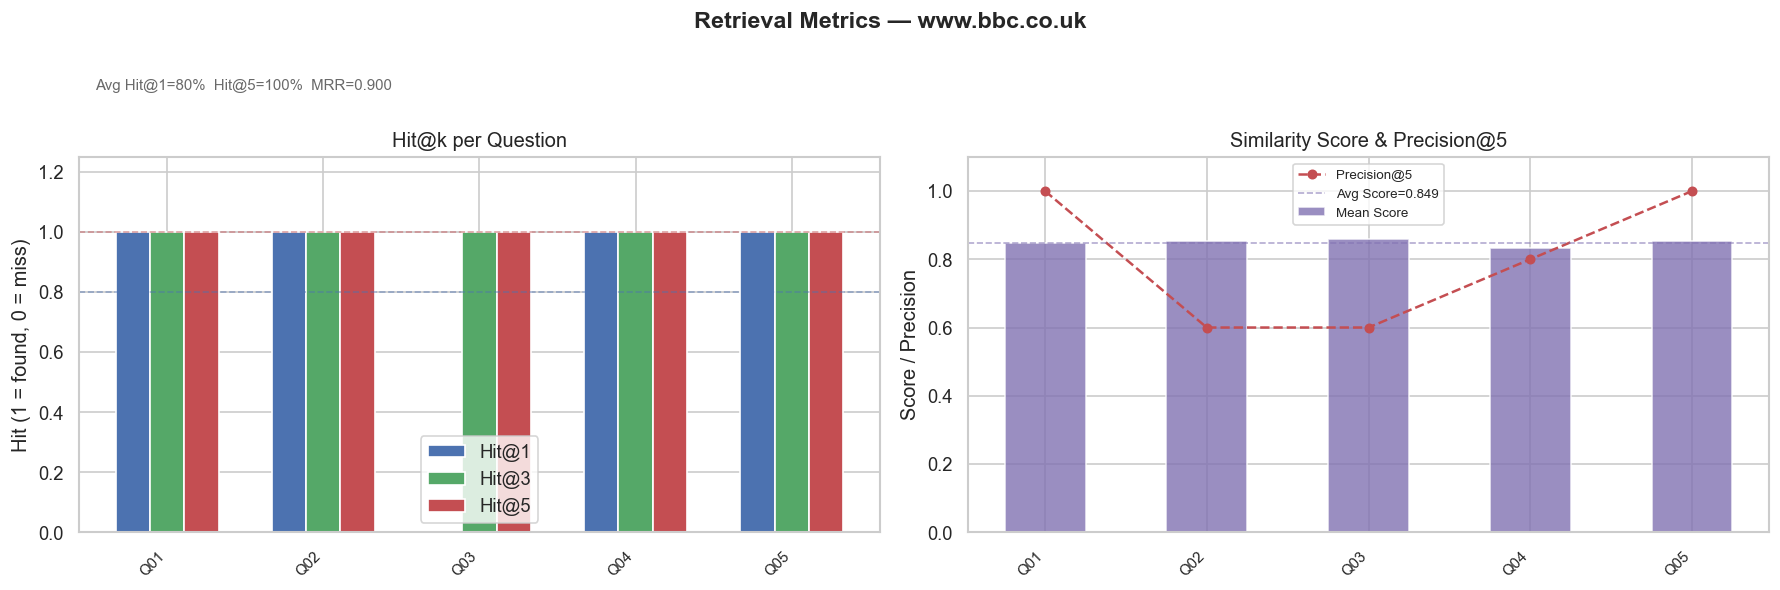

Saved: data/eval_retrieval_chart.png


In [10]:
labels  = [f'Q{r["idx"]:02d}' for r in retrieval_rows]
hit1    = [r['hit@1'] for r in retrieval_rows]
hit3    = [r['hit@3'] for r in retrieval_rows]
hit5    = [r['hit@5'] for r in retrieval_rows]
mrr     = [r['mrr@5'] for r in retrieval_rows]
scores  = [r['mean_score'] for r in retrieval_rows]
prec    = [r['precision@5'] for r in retrieval_rows]

x = np.arange(len(labels))
w = 0.22

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle(f'Retrieval Metrics — {SITE_LABEL}', fontsize=14, fontweight='bold')

# ── Left: Hit@k grouped bar ───────────────────────────────────────────────────
ax = axes[0]
ax.bar(x - w, hit1, w, label='Hit@1', color='#4C72B0')
ax.bar(x,     hit3, w, label='Hit@3', color='#55A868')
ax.bar(x + w, hit5, w, label='Hit@5', color='#C44E52')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=9)
ax.set_ylim(0, 1.25)
ax.set_ylabel('Hit (1 = found, 0 = miss)')
ax.set_title('Hit@k per Question')
ax.legend()
ax.axhline(np.mean(hit1), color='#4C72B0', ls='--', lw=1, alpha=0.5)
ax.axhline(np.mean(hit5), color='#C44E52', ls='--', lw=1, alpha=0.5)
# Summary text
ax.text(0.02, 1.18, f'Avg Hit@1={np.mean(hit1):.0%}  Hit@5={np.mean(hit5):.0%}  MRR={np.mean(mrr):.3f}',
        transform=ax.transAxes, fontsize=9, color='dimgray')

# ── Right: Mean similarity score + Precision@5 line ──────────────────────────
ax2 = axes[1]
bars = ax2.bar(x, scores, 0.5, label='Mean Score', color='#8172B2', alpha=0.8)
ax2.plot(x, prec, 'o--', color='#C44E52', lw=1.5, ms=5, label='Precision@5')
ax2.set_xticks(x)
ax2.set_xticklabels(labels, rotation=45, ha='right', fontsize=9)
ax2.set_ylim(0, 1.1)
ax2.set_ylabel('Score / Precision')
ax2.set_title('Similarity Score & Precision@5')
ax2.axhline(np.mean(scores), color='#8172B2', ls='--', lw=1, alpha=0.6, label=f'Avg Score={np.mean(scores):.3f}')
ax2.legend(fontsize=8)

plt.tight_layout()
plt.savefig(DATA_DIR / 'eval_retrieval_chart.png', bbox_inches='tight')
plt.show()
print('Saved: data/eval_retrieval_chart.png')

## 6. Charts — Faithfulness Metrics

C:\Users\shiva\AppData\Local\Temp\ipykernel_28212\293825450.py:50: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\shiva\AppData\Local\Temp\ipykernel_28212\293825450.py:51: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.savefig(DATA_DIR / 'eval_faithfulness_chart.png', bbox_inches='tight')
c:\Users\shiva\miniforge3\envs\webin\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


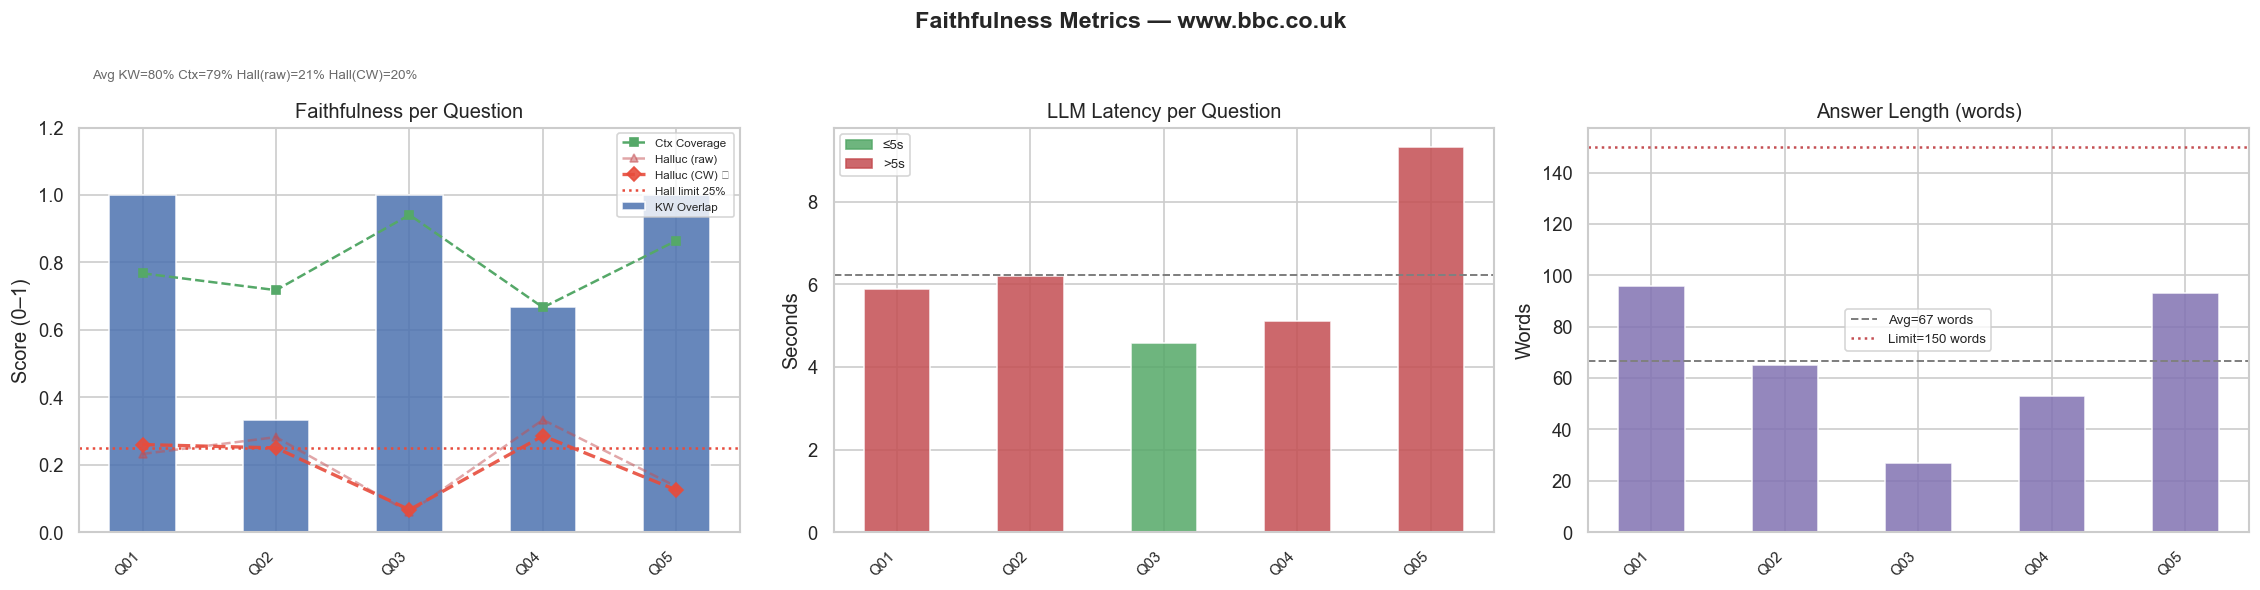

Saved: data/eval_faithfulness_chart.png


In [11]:
f_labels   = [f'Q{r["idx"]:02d}' for r in faithfulness_rows]
kw_ovlp    = [r['kw_overlap'] for r in faithfulness_rows]
ctx_cov    = [r['ctx_coverage'] for r in faithfulness_rows]
halluc     = [r['hallucination'] for r in faithfulness_rows]      # legacy (all-word)
halluc_cw  = [r['hallucination_cw'] for r in faithfulness_rows]   # content-word (primary)
latencies  = [r['latency_s'] for r in faithfulness_rows]
words      = [r['answer_words'] for r in faithfulness_rows]

fig, axes = plt.subplots(1, 3, figsize=(19, 5))
fig.suptitle(f'Faithfulness Metrics — {SITE_LABEL}', fontsize=14, fontweight='bold')
fx = np.arange(len(f_labels))

# ── Left: Faithfulness overview ───────────────────────────────────────────────
ax = axes[0]
ax.bar(fx, kw_ovlp, 0.5, label='KW Overlap', color='#4C72B0', alpha=0.85)
ax.plot(fx, ctx_cov,   's--', color='#55A868', lw=1.5, ms=5, label='Ctx Coverage')
ax.plot(fx, halluc,    '^--', color='#C44E52', lw=1.5, ms=5, label='Halluc (raw)',   alpha=0.5)
ax.plot(fx, halluc_cw, 'D--', color='#e74c3c', lw=2.0, ms=6, label='Halluc (CW) ★', alpha=0.9)
ax.axhline(RAG_QA_THRESHOLDS['hallucination_max'], color='#e74c3c', ls=':', lw=1.5,
           label=f'Hall limit {RAG_QA_THRESHOLDS["hallucination_max"]:.0%}')
ax.set_xticks(fx); ax.set_xticklabels(f_labels, rotation=45, ha='right', fontsize=9)
ax.set_ylim(0, 1.2); ax.set_ylabel('Score (0–1)'); ax.set_title('Faithfulness per Question')
ax.legend(fontsize=7)
ax.text(0.02, 1.12,
        f'Avg KW={np.mean(kw_ovlp):.0%} Ctx={np.mean(ctx_cov):.0%} '
        f'Hall(raw)={np.mean(halluc):.0%} Hall(CW)={np.mean(halluc_cw):.0%}',
        transform=ax.transAxes, fontsize=8, color='dimgray')

# ── Middle: LLM latency ───────────────────────────────────────────────────────
ax = axes[1]
colors = ['#C44E52' if l > 5 else '#55A868' for l in latencies]
ax.bar(fx, latencies, 0.5, color=colors, alpha=0.85)
ax.axhline(np.mean(latencies), color='gray', ls='--', lw=1.2, label=f'Avg={np.mean(latencies):.1f}s')
ax.set_xticks(fx); ax.set_xticklabels(f_labels, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Seconds'); ax.set_title('LLM Latency per Question')
green_p = mpatches.Patch(color='#55A868', alpha=0.85, label='≤5s')
red_p   = mpatches.Patch(color='#C44E52', alpha=0.85, label='>5s')
ax.legend(handles=[green_p, red_p], fontsize=8)

# ── Right: Answer length + word threshold ─────────────────────────────────────
ax = axes[2]
ax.bar(fx, words, 0.5, color='#8172B2', alpha=0.85)
ax.axhline(np.mean(words), color='gray', ls='--', lw=1.2, label=f'Avg={np.mean(words):.0f} words')
ax.axhline(RAG_QA_THRESHOLDS['answer_words_max'], color='#C44E52', ls=':', lw=1.5,
           label=f'Limit={RAG_QA_THRESHOLDS["answer_words_max"]} words')
ax.set_xticks(fx); ax.set_xticklabels(f_labels, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Words'); ax.set_title('Answer Length (words)')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(DATA_DIR / 'eval_faithfulness_chart.png', bbox_inches='tight')
plt.show()
print('Saved: data/eval_faithfulness_chart.png')


## 7. Eval Matrix Heatmap — All Metrics per Question

C:\Users\shiva\AppData\Local\Temp\ipykernel_28212\3949717509.py:53: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\shiva\AppData\Local\Temp\ipykernel_28212\3949717509.py:54: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.savefig(DATA_DIR / 'eval_matrix_heatmap.png', bbox_inches='tight')
c:\Users\shiva\miniforge3\envs\webin\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


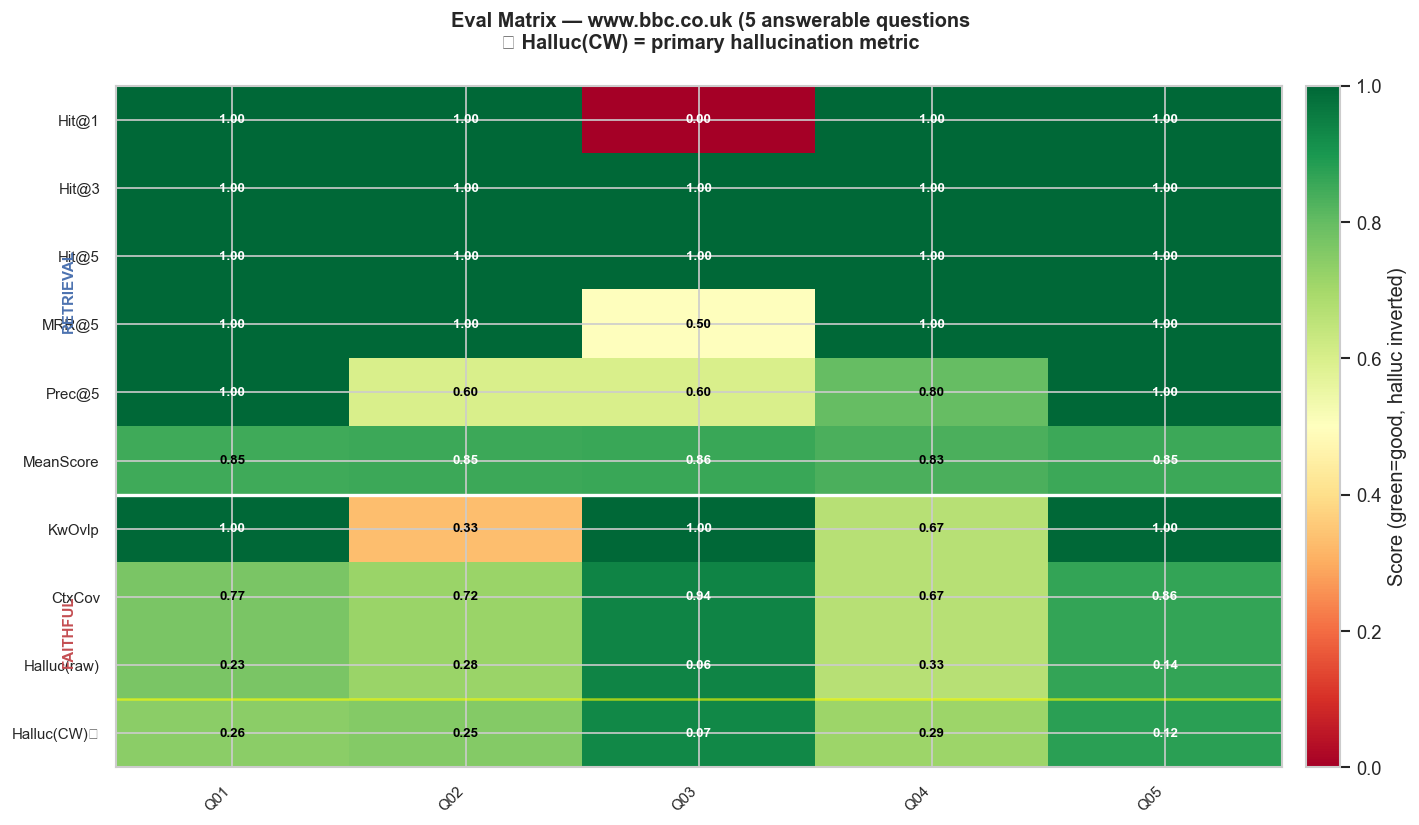

Saved: data/eval_matrix_heatmap.png


In [12]:
n = len(ANSWERABLE_QA)
hall_cw_vals = [r['hallucination_cw'] for r in faithfulness_rows]
metric_names = ['Hit@1', 'Hit@3', 'Hit@5', 'MRR@5', 'Prec@5', 'MeanScore',
                'KwOvlp', 'CtxCov', 'Halluc(raw)', 'Halluc(CW)★']

matrix = np.array([
    [r['hit@1'] for r in retrieval_rows],
    [r['hit@3'] for r in retrieval_rows],
    [r['hit@5'] for r in retrieval_rows],
    [r['mrr@5'] for r in retrieval_rows],
    [r['precision@5'] for r in retrieval_rows],
    [r['mean_score'] for r in retrieval_rows],
    [r['kw_overlap'] for r in faithfulness_rows],
    [r['ctx_coverage'] for r in faithfulness_rows],
    [r['hallucination'] for r in faithfulness_rows],
    hall_cw_vals,
])

display_matrix = matrix.copy()
display_matrix[8] = 1.0 - display_matrix[8]   # flip raw halluc
display_matrix[9] = 1.0 - display_matrix[9]   # flip CW halluc

col_labels = [f'Q{r["idx"]:02d}' for r in retrieval_rows]

fig, ax = plt.subplots(figsize=(max(12, n * 1.0), 7))
fig.suptitle(f'Eval Matrix — {SITE_LABEL} ({n} answerable questions\n★ Halluc(CW) = primary hallucination metric',
             fontsize=12, fontweight='bold')

im = ax.imshow(display_matrix, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')

ax.set_xticks(np.arange(n)); ax.set_yticks(np.arange(len(metric_names)))
ax.set_xticklabels(col_labels, fontsize=9)
ax.set_yticklabels(metric_names, fontsize=9)
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

for i in range(len(metric_names)):
    for j in range(n):
        val = matrix[i, j]
        disp_val = display_matrix[i, j]
        text_color = 'black' if 0.3 < disp_val < 0.85 else 'white'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                fontsize=8, color=text_color, fontweight='bold')

ax.axhline(5.5, color='white', lw=2)
ax.axhline(8.5, color='yellow', lw=1.5, alpha=0.6)

ax.text(-0.7, 2.5, 'RETRIEVAL', ha='center', va='center', rotation=90,
        fontsize=9, fontweight='bold', color='#4C72B0', transform=ax.transData)
ax.text(-0.7, 7.5, 'FAITHFUL', ha='center', va='center', rotation=90,
        fontsize=9, fontweight='bold', color='#C44E52', transform=ax.transData)

plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02, label='Score (green=good, halluc inverted)')
plt.tight_layout()
plt.savefig(DATA_DIR / 'eval_matrix_heatmap.png', bbox_inches='tight')
plt.show()
print('Saved: data/eval_matrix_heatmap.png')


## 8. Radar Chart — Aggregate Profile

C:\Users\shiva\AppData\Local\Temp\ipykernel_28212\3649571244.py:54: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\shiva\AppData\Local\Temp\ipykernel_28212\3649571244.py:55: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.savefig(DATA_DIR / 'eval_radar_chart.png', bbox_inches='tight')
c:\Users\shiva\miniforge3\envs\webin\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


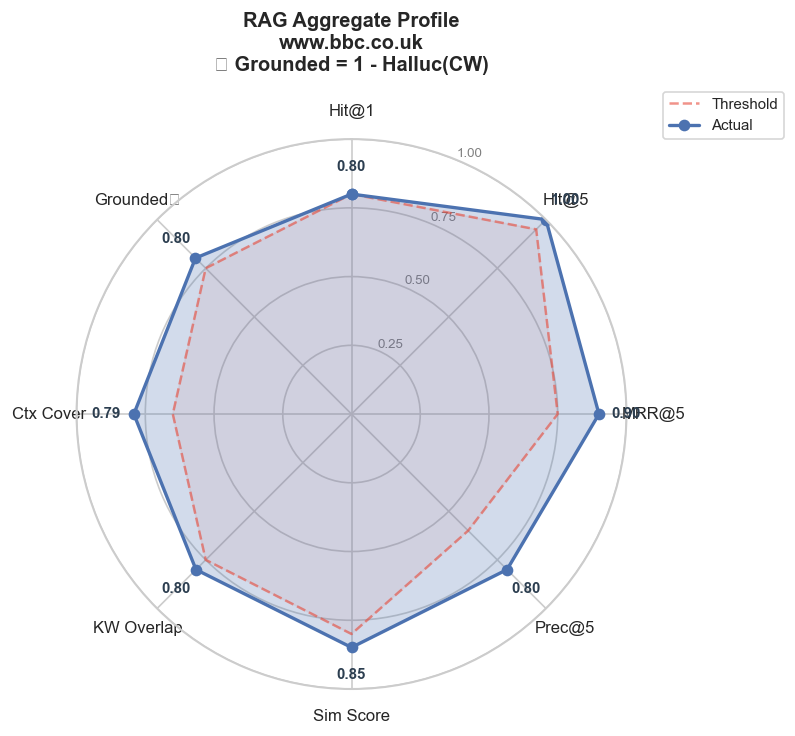

Saved: data/eval_radar_chart.png


In [13]:
hall_cw_vals = [r['hallucination_cw'] for r in faithfulness_rows]

radar_labels = ['Hit@1', 'Hit@5', 'MRR@5', 'Prec@5', 'Sim Score', 'KW Overlap', 'Ctx Cover', 'Grounded★']
radar_vals = [
    np.mean(hit1),
    np.mean(hit5),
    np.mean(mrr),
    np.mean(prec),
    np.mean(scores),
    np.mean(kw_ovlp),
    np.mean(ctx_cov),
    1.0 - np.mean(hall_cw_vals),   # grounded = 1 - content-word hallucination (★ primary)
]

N = len(radar_labels)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
vals_plot  = radar_vals + [radar_vals[0]]
angles_plot = angles + [angles[0]]

# Threshold polygon
thr_vals = [
    RAG_QA_THRESHOLDS['hit@1_min'],
    RAG_QA_THRESHOLDS['hit@5_min'],
    RAG_QA_THRESHOLDS['mrr@5_min'],
    0.6,   # Prec@5 indicative
    0.80,  # Sim Score indicative
    RAG_QA_THRESHOLDS['kw_overlap_min'],
    RAG_QA_THRESHOLDS['ctx_coverage_min'],
    1.0 - RAG_QA_THRESHOLDS['hallucination_max'],
]
thr_plot = thr_vals + [thr_vals[0]]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
ax.set_theta_offset(np.pi / 2); ax.set_theta_direction(-1)

ax.plot(angles_plot, thr_plot, '--', lw=1.5, color='#e74c3c', alpha=0.6, label='Threshold')
ax.fill(angles_plot, thr_plot, alpha=0.08, color='#e74c3c')

ax.plot(angles_plot, vals_plot, 'o-', lw=2, color='#4C72B0', label='Actual')
ax.fill(angles_plot, vals_plot, alpha=0.25, color='#4C72B0')

ax.set_thetagrids(np.degrees(angles), radar_labels, fontsize=10)
ax.set_ylim(0, 1)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(['0.25','0.50','0.75','1.00'], fontsize=8, color='gray')
ax.set_title(f'RAG Aggregate Profile\n{SITE_LABEL}\n★ Grounded = 1 - Halluc(CW)',
             size=12, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=9)

for angle, val, label in zip(angles, radar_vals, radar_labels):
    ax.text(angle, val + 0.1, f'{val:.2f}', ha='center', va='center',
            fontsize=9, fontweight='bold', color='#2c3e50')

plt.tight_layout()
plt.savefig(DATA_DIR / 'eval_radar_chart.png', bbox_inches='tight')
plt.show()
print('Saved: data/eval_radar_chart.png')


## 9. Score Distribution Histograms

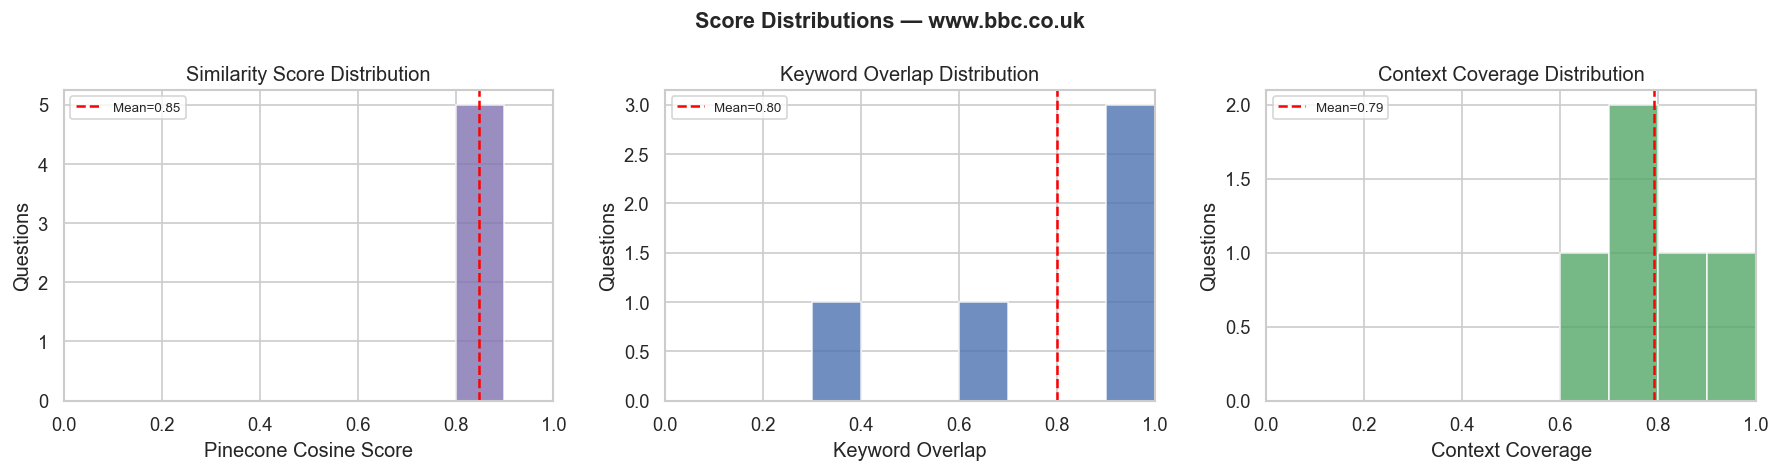

Saved: data/eval_distributions.png


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle(f'Score Distributions — {SITE_LABEL}', fontsize=13, fontweight='bold')

def hist(ax, data, title, color, xlabel):
    ax.hist(data, bins=10, range=(0, 1), color=color, alpha=0.8, edgecolor='white')
    ax.axvline(np.mean(data), color='red', ls='--', lw=1.5, label=f'Mean={np.mean(data):.2f}')
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Questions')
    ax.legend(fontsize=8)
    ax.set_xlim(0, 1)

hist(axes[0], scores,   'Similarity Score Distribution', '#8172B2', 'Pinecone Cosine Score')
hist(axes[1], kw_ovlp,  'Keyword Overlap Distribution',  '#4C72B0', 'Keyword Overlap')
hist(axes[2], ctx_cov,  'Context Coverage Distribution',  '#55A868', 'Context Coverage')

plt.tight_layout()
plt.savefig(DATA_DIR / 'eval_distributions.png', bbox_inches='tight')
plt.show()
print('Saved: data/eval_distributions.png')

## 10. Printed Metric Tables

In [15]:
# ── Retrieval table ───────────────────────────────────────────────────────────
print(f'RETRIEVAL TABLE — {SITE_LABEL}')
print('─' * 82)
print(f'{"Q#":<4} {"Hit@1":>6} {"Hit@3":>6} {"Hit@5":>6} {"MRR@5":>6} {"Prec@5":>7} {"Score":>6}  Question')
print('─' * 82)
for r in retrieval_rows:
    tag = '' if r['hit@5'] else ' ✗'
    print(f'Q{r["idx"]:02d}  {r["hit@1"]:>6} {r["hit@3"]:>6} {r["hit@5"]:>6} '
          f'{r["mrr@5"]:>6.2f} {r["precision@5"]:>7.0%} {r["mean_score"]:>6.3f}  {r["q"][:38]}{tag}')
print('─' * 82)
print(f'{"AVG":<4} {np.mean(hit1):>6.0%} {np.mean(hit3):>6.0%} {np.mean(hit5):>6.0%} '
      f'{np.mean(mrr):>6.3f} {np.mean(prec):>7.0%} {np.mean(scores):>6.3f}')
print()

# ── Faithfulness table ────────────────────────────────────────────────────────
print(f'FAITHFULNESS TABLE — {SITE_LABEL}')
print('─' * 82)
print(f'{"Q#":<4} {"KwOvlp":>7} {"CtxCov":>7} {"Halluc":>7} {"Words":>6} {"Src":>4} {"Lat(s)":>7}  Question')
print('─' * 82)
for r in faithfulness_rows:
    flag = ' !' if r['hallucination'] > 0.55 else ''
    print(f'Q{r["idx"]:02d}  {r["kw_overlap"]:>7.0%} {r["ctx_coverage"]:>7.0%} '
          f'{r["hallucination"]:>7.0%} {r["answer_words"]:>6} {r["num_sources"]:>4} '
          f'{r["latency_s"]:>7.1f}  {r["question"][:32]}{flag}')
print('─' * 82)
print(f'{"AVG":<4} {np.mean(kw_ovlp):>7.0%} {np.mean(ctx_cov):>7.0%} '
      f'{np.mean(halluc):>7.0%} {np.mean(words):>6.0f} '
      f'{np.mean([r["num_sources"] for r in faithfulness_rows]):>4.1f} '
      f'{np.mean(latencies):>7.1f}')

RETRIEVAL TABLE — www.bbc.co.uk
──────────────────────────────────────────────────────────────────────────────────
Q#    Hit@1  Hit@3  Hit@5  MRR@5  Prec@5  Score  Question
──────────────────────────────────────────────────────────────────────────────────
Q01       1      1      1   1.00    100%  0.848  What is the BBC?
Q02       1      1      1   1.00     60%  0.853  How is the BBC funded?
Q03       0      1      1   0.50     60%  0.858  What is the mission of the BBC?
Q04       1      1      1   1.00     80%  0.833  Is the BBC independent from the govern
Q05       1      1      1   1.00    100%  0.853  What services does the BBC provide?
──────────────────────────────────────────────────────────────────────────────────
AVG     80%   100%   100%  0.900     80%  0.849

FAITHFULNESS TABLE — www.bbc.co.uk
──────────────────────────────────────────────────────────────────────────────────
Q#    KwOvlp  CtxCov  Halluc  Words  Src  Lat(s)  Question
───────────────────────────────────────────

## 10.5. Pass/Fail Quality Dashboard

Compares aggregate metrics against thresholds defined in Section 0.
**Scope: Site Q&A chatbot only** — Insights generation is exempt.


In [16]:
print('=' * 68)
print(f'  PASS / FAIL DASHBOARD — {SITE_LABEL}')
print(f'  Scope: Site Q&A chatbot (NOT Insights generation)')
print('=' * 68)

hall_cw_vals = [r['hallucination_cw'] for r in faithfulness_rows]
ctx_tok_vals = [r['ctx_tokens'] for r in faithfulness_rows]
words        = [r['answer_words'] for r in faithfulness_rows]

# ── ANSWERABLE TRACK ─────────────────────────────────────────────────────────
print(f'  ANSWERABLE TRACK  ({len(ANSWERABLE_QA)} questions)')
print('-' * 68)

answerable_checks = [
    ('Hit@1',        np.mean(hit1),              RAG_QA_THRESHOLDS['hit@1_min'],        'min'),
    ('Hit@5',        np.mean(hit5),              RAG_QA_THRESHOLDS['hit@5_min'],        'min'),
    ('MRR@5',        np.mean(mrr),               RAG_QA_THRESHOLDS['mrr@5_min'],        'min'),
    ('Halluc CW',    np.mean(hall_cw_vals),      RAG_QA_THRESHOLDS['hallucination_max'],'max'),
    ('Ctx Coverage', np.mean(ctx_cov),           RAG_QA_THRESHOLDS['ctx_coverage_min'], 'min'),
    ('KW Overlap',   np.mean(kw_ovlp),           RAG_QA_THRESHOLDS['kw_overlap_min'],   'min'),
    ('Ans Words',    np.mean(words),             RAG_QA_THRESHOLDS['answer_words_max'], 'max'),
    ('Ctx Tokens',   np.mean(ctx_tok_vals),      RAG_QA_THRESHOLDS['ctx_tokens_max'],   'max'),
]

ans_pass = 0
for name, value, threshold, mode in answerable_checks:
    status, delta = threshold_check(name, value, threshold, mode)
    if '✅' in status:
        ans_pass += 1
    if name in ('Hit@1','Hit@5','Halluc CW','Ctx Coverage','KW Overlap'):
        val_s = f'{value:.1%}'; thr_s = f'{threshold:.0%}'
    elif name == 'MRR@5':
        val_s = f'{value:.3f}'; thr_s = f'{threshold:.2f}'
    else:
        val_s = f'{value:.0f}';  thr_s = f'{threshold}'
    delta_s = f'({delta:+.1%})' if name not in ('MRR@5','Ans Words','Ctx Tokens') else f'({delta:+.0f})'
    print(f'  {status}  {name:<14} {val_s:<8} threshold={thr_s}  Δ={delta_s}')

print()

# ── UNANSWERABLE TRACK ───────────────────────────────────────────────────────
if rejection_rows:
    print(f'  UNANSWERABLE TRACK  ({len(UNANSWERABLE_QA)} questions)')
    print('-' * 68)
    rejection_rate = sum(r['abstained'] for r in rejection_rows) / len(rejection_rows)
    rr_status, rr_delta = threshold_check('rejection_rate', rejection_rate,
                                           RAG_QA_THRESHOLDS['rejection_rate_min'])
    print(f'  {rr_status}  Rejection Rate   {rejection_rate:.1%}    threshold=≥{RAG_QA_THRESHOLDS["rejection_rate_min"]:.0%}'
          f'  Δ=({rr_delta:+.1%})')
    for r in rejection_rows:
        mark = '✅' if r['abstained'] else '❌'
        print(f'       {mark} {r["label"]}: {"correctly refused" if r["abstained"] else "HALLUCINATED"}'
              f' ({r["answer_words"]} words) | {r["question"][:50]}')
    rej_pass = 1 if '✅' in rr_status else 0
    total_checks = len(answerable_checks) + 1
else:
    print('  UNANSWERABLE TRACK  — no questions defined')
    rej_pass = 0
    total_checks = len(answerable_checks)

print()
print('=' * 68)
total_pass = ans_pass + rej_pass
print(f'  Score: {total_pass}/{total_checks} checks passed')

if total_pass == total_checks:
    print('  ✅ ALL CHECKS PASS — RAG quality meets Q&A threshold')
else:
    fails = total_checks - total_pass
    print(f'  ❌ {fails} check(s) FAILED — review metrics above')
print('=' * 68)

# ── Verbosity violations ──────────────────────────────────────────────────────
verbose_qs = [r for r in faithfulness_rows if r['verbosity_score'] > 0]
if verbose_qs:
    WORD_CAP = RAG_QA_THRESHOLDS['answer_words_max']
    print(f'\nVerbosity violations (>{WORD_CAP} words):')
    for r in verbose_qs:
        print(f'  {r["label"]}: {r["answer_words"]} words (+{r["answer_words"]-WORD_CAP} over) | {r["question"][:50]}')
    print('  Fix: prompt cap already set to 150w in rag.py — re-run to verify.')


  PASS / FAIL DASHBOARD — www.bbc.co.uk
  Scope: Site Q&A chatbot (NOT Insights generation)
  ANSWERABLE TRACK  (5 questions)
--------------------------------------------------------------------
  ✅ PASS  Hit@1          80.0%    threshold=80%  Δ=(+0.0%)
  ✅ PASS  Hit@5          100.0%   threshold=95%  Δ=(+5.0%)
  ✅ PASS  MRR@5          0.900    threshold=0.75  Δ=(+0)
  ✅ PASS  Halluc CW      19.7%    threshold=25%  Δ=(+5.3%)
  ✅ PASS  Ctx Coverage   79.2%    threshold=65%  Δ=(+14.2%)
  ✅ PASS  KW Overlap     80.0%    threshold=75%  Δ=(+5.0%)
  ✅ PASS  Ans Words      67       threshold=150  Δ=(+83)
  ✅ PASS  Ctx Tokens     937      threshold=3000  Δ=(+2063)

  UNANSWERABLE TRACK  (2 questions)
--------------------------------------------------------------------
  ✅ PASS  Rejection Rate   100.0%    threshold=≥90%  Δ=(+10.0%)
       ✅ U01: correctly refused (10 words) | What is the BBC pension fund total asset value?
       ✅ U02: correctly refused (10 words) | How many BBC journalists we

## 11. Baseline Summary Box

In [17]:
hall_cw_vals = [r['hallucination_cw'] for r in faithfulness_rows]
ctx_tok_vals = [r['ctx_tokens'] for r in faithfulness_rows]
words        = [r['answer_words'] for r in faithfulness_rows]

def pf(val, thr, mode='min'):
    return '✅' if (val >= thr if mode == 'min' else val <= thr) else '❌'

W = 68
print('╔' + '═' * W + '╗')
print(f'║  RAG BASELINE — {SITE_LABEL:<{W-16}} ║')
print('╠' + '═' * W + '╣')
print(f'║  Questions (answerable)   : {len(ANSWERABLE_QA):<{W-29}} ║')
print(f'║  Questions (unanswerable) : {len(UNANSWERABLE_QA):<{W-29}} ║')
print(f'║  Chunks                   : {len(session["chunks"]):<{W-29}} ║')
print(f'║  Top-k                    : {TOP_K:<{W-29}} ║')
print(f'║  Stopwords                : {_SW_SOURCE:<{W-29}} ║')
print('╠' + '═' * W + '╣')
print(f'║  ANSWERABLE TRACK — RETRIEVAL           threshold  pass  ║')
print(f'║    Hit@1        : {np.mean(hit1):>6.1%}          ≥{RAG_QA_THRESHOLDS["hit@1_min"]:.0%}     {pf(np.mean(hit1), RAG_QA_THRESHOLDS["hit@1_min"])}     ║')
print(f'║    Hit@5        : {np.mean(hit5):>6.1%}          ≥{RAG_QA_THRESHOLDS["hit@5_min"]:.0%}     {pf(np.mean(hit5), RAG_QA_THRESHOLDS["hit@5_min"])}     ║')
print(f'║    MRR@5        : {np.mean(mrr):>6.3f}          ≥{RAG_QA_THRESHOLDS["mrr@5_min"]:.2f}    {pf(np.mean(mrr), RAG_QA_THRESHOLDS["mrr@5_min"])}     ║')
print(f'║    Precision@5  : {np.mean(prec):>6.1%}                              ║')
print(f'║    Mean Score   : {np.mean(scores):>6.3f}                              ║')
print('╠' + '═' * W + '╣')
print(f'║  ANSWERABLE TRACK — FAITHFULNESS        threshold  pass  ║')
print(f'║    KW Overlap        : {np.mean(kw_ovlp):>6.1%}       ≥{RAG_QA_THRESHOLDS["kw_overlap_min"]:.0%}     {pf(np.mean(kw_ovlp), RAG_QA_THRESHOLDS["kw_overlap_min"])}     ║')
print(f'║    Ctx Coverage      : {np.mean(ctx_cov):>6.1%}       ≥{RAG_QA_THRESHOLDS["ctx_coverage_min"]:.0%}     {pf(np.mean(ctx_cov), RAG_QA_THRESHOLDS["ctx_coverage_min"])}     ║')
print(f'║    Halluc (raw)      : {np.mean(halluc):>6.1%}       (all-word proxy)         ║')
print(f'║    Halluc (CW)  ★    : {np.mean(hall_cw_vals):>6.1%}       ≤{RAG_QA_THRESHOLDS["hallucination_max"]:.0%}     {pf(np.mean(hall_cw_vals), RAG_QA_THRESHOLDS["hallucination_max"], "max")}     ║')
print(f'║    Avg Words         : {np.mean(words):>6.0f}       ≤{RAG_QA_THRESHOLDS["answer_words_max"]}    {pf(np.mean(words), RAG_QA_THRESHOLDS["answer_words_max"], "max")}     ║')
print(f'║    Avg Ctx Tokens    : {np.mean(ctx_tok_vals):>6.0f}       ≤{RAG_QA_THRESHOLDS["ctx_tokens_max"]}  {pf(np.mean(ctx_tok_vals), RAG_QA_THRESHOLDS["ctx_tokens_max"], "max")}     ║')
print(f'║    Avg Latency       : {np.mean(latencies):>6.1f}s                               ║')
print('╠' + '═' * W + '╣')
if rejection_rows:
    rejection_rate = sum(r['abstained'] for r in rejection_rows) / len(rejection_rows)
    print(f'║  UNANSWERABLE TRACK — REJECTION         threshold  pass  ║')
    print(f'║    Rejection Rate    : {rejection_rate:>6.1%}       ≥{RAG_QA_THRESHOLDS["rejection_rate_min"]:.0%}     {pf(rejection_rate, RAG_QA_THRESHOLDS["rejection_rate_min"])}     ║')
else:
    print(f'║  UNANSWERABLE TRACK — no questions defined                    ║')
print('╠' + '═' * W + '╣')
print(f'║  {"⚠ Thresholds: Q&A chatbot only (NOT insights)":<{W}} ║')
print('╚' + '═' * W + '╝')


╔════════════════════════════════════════════════════════════════════╗
║  RAG BASELINE — www.bbc.co.uk                                        ║
╠════════════════════════════════════════════════════════════════════╣
║  Questions (answerable)   : 5                                       ║
║  Questions (unanswerable) : 2                                       ║
║  Chunks                   : 782                                     ║
║  Top-k                    : 5                                       ║
║  Stopwords                : NLTK (184 words, negations retained)    ║
╠════════════════════════════════════════════════════════════════════╣
║  ANSWERABLE TRACK — RETRIEVAL           threshold  pass  ║
║    Hit@1        :  80.0%          ≥80%     ✅     ║
║    Hit@5        : 100.0%          ≥95%     ✅     ║
║    MRR@5        :  0.900          ≥0.75    ✅     ║
║    Precision@5  :  80.0%                              ║
║    Mean Score   :  0.849                              ║
╠═════════════════

## 12. Inspect Individual Answers

In [18]:
# Change Q_IDX to inspect any question (1-based)
Q_IDX = 1

rr = retrieval_rows[Q_IDX - 1]
fr = faithfulness_rows[Q_IDX - 1]

print(f'Q{Q_IDX:02d}: {rr["q"]}')
print(f'Ground truth : {rr["gt"]}')
print(f'Keywords     : {rr["kw"]}')
print()
print(f'RETRIEVAL  hit@1={rr["hit@1"]} hit@5={rr["hit@5"]} mrr={rr["mrr@5"]:.2f} score={rr["mean_score"]:.3f}')
print('Top chunks:')
for j, c in enumerate(rr['results'][:3], 1):
    print(f'  [{j}] score={c["score"]:.3f} | {c["chunk"]["section_title"]} | {c["chunk"]["text"][:120]}...')
print()
print(f'FAITHFULNESS  kw={fr["kw_overlap"]:.0%} ctx={fr["ctx_coverage"]:.0%} hall={fr["hallucination"]:.0%}')
print(f'ANSWER ({fr["answer_words"]} words):')
print(fr['answer'])

Q01: What is the BBC?
Ground truth : The BBC is the United Kingdom public service broadcaster.
Keywords     : ['bbc', 'public service', 'broadcaster', 'uk']

RETRIEVAL  hit@1=1 hit@5=1 mrr=1.00 score=0.848
Top chunks:
  [1] score=0.859 | BBC World Service | The BBC is the world’s most trusted international news broadcaster – committed to providing accurate, impartial, and ind...
  [2] score=0.848 | Learn more about what we do | Learn more about what we do Everything you need to know about the workings of the BBC...
  [3] score=0.845 | The BBC is the world’s leading public service broadcaster | We’re impartial and independent, and every day we create distinctive, world-class programmes and content which inform, e...

FAITHFULNESS  kw=100% ctx=77% hall=23%
ANSWER (96 words):
**BBC Overview**

- The **BBC** is the world’s leading **public service broadcaster**, offering impartial and independent programmes that inform, educate and entertain millions in the UK and worldwide.  
- It operate

## 13. Save Results

In [20]:
hall_cw_vals = [r['hallucination_cw'] for r in faithfulness_rows]
ctx_tok_vals = [r['ctx_tokens'] for r in faithfulness_rows]
words        = [r['answer_words'] for r in faithfulness_rows]
rejection_rate = (sum(r['abstained'] for r in rejection_rows) / len(rejection_rows)
                  if rejection_rows else None)

output = {
    'eval_date':    datetime.datetime.utcnow().isoformat(),
    'site':         SITE_LABEL,
    'session_id':   SESSION_ID,
    'top_k':        TOP_K,
    'stopwords_source': _SW_SOURCE,
    'thresholds':   RAG_QA_THRESHOLDS,
    'question_counts': {
        'answerable':   len(ANSWERABLE_QA),
        'unanswerable': len(UNANSWERABLE_QA),
    },
    # ── Answerable track ─────────────────────────────────────────────────────
    'retrieval_summary': {
        'hit@1': float(np.mean(hit1)),   'hit@3': float(np.mean(hit3)),
        'hit@5': float(np.mean(hit5)),   'mrr@5': float(np.mean(mrr)),
        'precision@5': float(np.mean(prec)),
        'mean_score': float(np.mean(scores)),
    },
    'faithfulness_summary': {
        'kw_overlap':        float(np.mean(kw_ovlp)),
        'ctx_coverage':      float(np.mean(ctx_cov)),
        'hallucination_raw': float(np.mean(halluc)),
        'hallucination_cw':  float(np.mean(hall_cw_vals)),
        'avg_words':         float(np.mean(words)),
        'avg_ctx_tokens':    float(np.mean(ctx_tok_vals)),
        'avg_latency_s':     float(np.mean(latencies)),
    },
    # ── Unanswerable track ────────────────────────────────────────────────────
    'rejection_summary': {
        'rejection_rate':  float(rejection_rate) if rejection_rate is not None else None,
        'n_unanswerable':  len(rejection_rows),
        'n_abstained':     sum(r['abstained'] for r in rejection_rows),
    },
    # ── Per-question detail ───────────────────────────────────────────────────
    'answerable_questions': [
        {
            'idx': rr['idx'],
            'question': rr['q'], 'ground_truth': rr['gt'], 'keywords': rr['kw'],
            'hit@1': rr['hit@1'], 'hit@3': rr['hit@3'], 'hit@5': rr['hit@5'],
            'mrr@5': rr['mrr@5'], 'precision@5': rr['precision@5'], 'mean_score': rr['mean_score'],
            'answer': fr['answer'],
            'kw_overlap': fr['kw_overlap'],
            'ctx_coverage': fr['ctx_coverage'],
            'hallucination_raw': fr['hallucination'],
            'hallucination_cw': fr['hallucination_cw'],
            'verbosity_score': fr['verbosity_score'],
            'answer_words': fr['answer_words'],
            'ctx_tokens': fr['ctx_tokens'],
            'latency_s': fr['latency_s'],
        }
        for rr, fr in zip(retrieval_rows, faithfulness_rows)
    ],
    'unanswerable_questions': [
        {
            'idx': r['idx'], 'label': r['label'],
            'question': r['question'], 'answer': r['answer'],
            'abstained': r['abstained'], 'answer_words': r['answer_words'],
            'latency_s': r['latency_s'],
        }
        for r in rejection_rows
    ],
}

out_path = DATA_DIR / f'eval_single_{SITE_LABEL}_{datetime.date.today()}.json'
out_path.write_text(json.dumps(output, indent=2, ensure_ascii=False), encoding='utf-8')
print(f'Results saved  : {out_path}')
print(f'Charts saved   : data/eval_retrieval_chart.png')
print(f'                 data/eval_faithfulness_chart.png')
print(f'                 data/eval_matrix_heatmap.png')
print(f'                 data/eval_radar_chart.png')
if rejection_rate is not None:
    print(f'Rejection rate : {rejection_rate:.0%} ({sum(r["abstained"] for r in rejection_rows)}/{len(rejection_rows)} refused)')


Results saved  : D:\dev\web-intelligence\data\eval_single_www.bbc.co.uk_2026-05-05.json
Charts saved   : data/eval_retrieval_chart.png
                 data/eval_faithfulness_chart.png
                 data/eval_matrix_heatmap.png
                 data/eval_radar_chart.png
Rejection rate : 100% (2/2 refused)
